Cell 1 — Imports

In [1]:

import os
import random
import numpy as np
import pandas as pd
import cv2

from PIL import Image

import torch
import torch.nn as nn

from torchvision import models
from torchvision.transforms import (
    Compose,
    ToTensor,
    Normalize
)

import matplotlib.pyplot as plt

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


PyTorch: 2.11.0+cu128
CUDA available: True


Cell 2 — Configuration


In [2]:
class Config:

    DEVICE = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    NUM_CLASSES = 5
    IMAGE_SIZE = 224

    RAW_CLINICAL_CSV_PATH = (
        r"D:\Diabetic Retinopathy Prediction\data\clinical_data.csv"
    )

    MULTIMODAL_MODEL_PATH = (
        r"D:\Diabetic Retinopathy Prediction\Models\best_multimodal_model.pth"
    )


print("Device:", Config.DEVICE)
print("Model path:", Config.MULTIMODAL_MODEL_PATH)

assert os.path.exists(
    Config.MULTIMODAL_MODEL_PATH
), "Multimodal model checkpoint not found!"

assert os.path.exists(
    Config.RAW_CLINICAL_CSV_PATH
), "Clinical CSV not found!"

Device: cuda
Model path: D:\Diabetic Retinopathy Prediction\Models\best_multimodal_model.pth


Cell 3 — Load Clinical Data and Fit Preprocessors


In [3]:
from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder
)
from sklearn.model_selection import train_test_split
clinical_df = pd.read_csv(
    Config.RAW_CLINICAL_CSV_PATH
)
train_df, val_df = train_test_split(
    clinical_df,
    test_size=0.2,
    random_state=42,
    stratify=clinical_df["DR_Grade"]
)
train_df = train_df.copy()
val_df = val_df.copy()
categorical_cols = [
    col for col in [
        "Gender",
        "Smoking_Status",
        "Hypertension",
        "Family_History"
    ]
    if col in clinical_df.columns
]
numerical_cols = [
    col for col in [
        "Age",
        "Duration_DM_Years",
        "HbA1c",
        "Fasting_Glucose_mg_dL",
        "BMI",
        "Systolic_BP",
        "Diastolic_BP",
        "Total_Cholesterol_mg_dL",
        "Serum_Creatinine_mg_dL"
    ]
    if col in clinical_df.columns
]
clinical_feature_cols = (
    categorical_cols
    + numerical_cols
)

# Missing value imputation

for col in categorical_cols:

    train_mode = (
        train_df[col].mode()[0]
        if not train_df[col].empty
        else "Never"
    )

    train_df[col] = (
        train_df[col]
        .fillna(train_mode)
    )

for col in numerical_cols:

    train_median = (
        train_df[col].median()
        if not train_df[col].empty
        else 0.0
    )

    train_df[col] = (
        train_df[col]
        .fillna(train_median)
    )

# Categorical encoding

clinical_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(
        train_df[col].astype(str)
    )
    clinical_encoders[col] = le


# Numerical normalization

clinical_scaler = StandardScaler()

if len(numerical_cols) > 0:

    train_df[numerical_cols] = (
        clinical_scaler.fit_transform(
            train_df[numerical_cols]
        )
    )
print(
    "Clinical features:",
    clinical_feature_cols
)
print(
    "Number of clinical features:",
    len(clinical_feature_cols)
)

Clinical features: ['Gender', 'Smoking_Status', 'Hypertension', 'Age', 'Duration_DM_Years', 'HbA1c', 'Fasting_Glucose_mg_dL', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'Total_Cholesterol_mg_dL', 'Serum_Creatinine_mg_dL']
Number of clinical features: 12


Cell 4 — Retina Image Preprocessing


In [4]:
def remove_black_borders(
    img,
    tolerance=10
):
    gray = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )
    _, thresh = cv2.threshold(
        gray,
        tolerance,
        255,
        cv2.THRESH_BINARY
    )
    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )
    if len(contours) > 0:

        c = max(
            contours,
            key=cv2.contourArea
        )
        x, y, w, h = cv2.boundingRect(c)

        return img[
            y:y+h,
            x:x+w
        ]
    return img

def preprocess_image_array(
    img,
    image_size=224
):
    # Remove black border
    img = remove_black_borders(img)

    h, w, _ = img.shape
    # Center crop
    crop_scale = 0.75
    new_h = int(
        h * crop_scale
    )
    new_w = int(
        w * crop_scale
    )
    center_x = w // 2
    center_y = h // 2

    x1 = max(
        0,
        center_x - new_w // 2
    )
    y1 = max(
        0,
        center_y - new_h // 2
    )
    x2 = min(
        w,
        x1 + new_w
    )
    y2 = min(
        h,
        y1 + new_h
    )
    img = img[
        y1:y2,
        x1:x2
    ]
    # Circular retina mask
    ch, cw, _ = img.shape

    mask = np.zeros(
        (ch, cw),
        dtype=np.uint8
    )
    cv2.circle(
        mask,
        (
            cw // 2,
            ch // 2
        ),
        int(
            0.49
            * min(ch, cw)
        ),
        255,
        -1
    )
    img = cv2.bitwise_and(
        img,
        img,
        mask=mask
    )
    # CLAHE
    lab = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2LAB
    )
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(
        clipLimit=3.0,
        tileGridSize=(8, 8)
    )
    l = clahe.apply(l)

    img = cv2.merge(
        (l, a, b)
    )
    img = cv2.cvtColor(
        img,
        cv2.COLOR_LAB2BGR
    )
    # Resize
    img = cv2.resize(
        img,
        (
            image_size,
            image_size
        )
    )
    return img
val_transforms = Compose([
    ToTensor(),

    Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],

        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])
print(
    "Image preprocessing loaded."
)

Image preprocessing loaded.


Cell 5 — Multimodal Model Architecture


In [5]:
class MultimodalDRClassifier(nn.Module):

    def __init__(
        self,
        num_clinical_features,
        num_classes=5
    ):
        super().__init__()

    # IMAGE MODEL
        self.image_model = (
            models.efficientnet_b4(
                weights=None
            )
        )

        in_features = (
            self.image_model
            .classifier[1]
            .in_features
        )
        self.image_model.classifier = (
            nn.Sequential(

                nn.Dropout(
                    p=0.4,
                    inplace=False
                ),

                nn.Linear(
                    in_features,
                    512
                ),

                nn.ReLU(
                    inplace=False
                ),

                nn.Dropout(
                    p=0.3,
                    inplace=False
                )
            )
        )
        
        # Disable inplace operations

        for module in (
            self.image_model.modules()
        ):

            if isinstance(
                module,
                (
                    nn.ReLU,
                    nn.SiLU
                )
            ):

                module.inplace = False

        # CLINICAL ENCODER

        self.clinical_encoder = (
            nn.Sequential(

                nn.Linear(
                    num_clinical_features,
                    64
                ),

                nn.BatchNorm1d(64),

                nn.ReLU(
                    inplace=False
                ),

                nn.Dropout(
                    p=0.2
                ),

                nn.Linear(
                    64,
                    32
                ),

                nn.ReLU(
                    inplace=False
                )
            )
        )

        # FUSION CLASSIFIER

        self.fusion_classifier = (
            nn.Sequential(

                nn.Linear(
                    512 + 32,
                    128
                ),

                nn.ReLU(
                    inplace=False
                ),

                nn.Dropout(
                    p=0.3
                ),

                nn.Linear(
                    128,
                    num_classes
                )
            )
        )

    def forward(
        self,
        image_tensor,
        clinical_tensor
    ):

        img_feats = self.image_model(
            image_tensor
        )

        clin_feats = self.clinical_encoder(
            clinical_tensor
        )

        fused = torch.cat(
            (
                img_feats,
                clin_feats
            ),
            dim=1
        )

        output = self.fusion_classifier(
            fused
        )

        return output

print(
    "Multimodal architecture loaded."
)

Multimodal architecture loaded.


Cell 6 — Load Your Trained Model


In [6]:
model = MultimodalDRClassifier(
    num_clinical_features=len(
        clinical_feature_cols
    ),
    num_classes=Config.NUM_CLASSES
)
state_dict = torch.load(
    Config.MULTIMODAL_MODEL_PATH,
    map_location=Config.DEVICE
)
model.load_state_dict(
    state_dict
)
model = model.to(
    Config.DEVICE
)
model.eval()
print(
    "Trained multimodal model loaded successfully."
)

Trained multimodal model loaded successfully.


Cell 7 — Improved Grad-CAM++


In [7]:
class GradCAMPlusPlus:

    def __init__(
        self,
        model,
        target_layer
    ):
        self.model = model

        self.target_layer = (
            target_layer
        )
        self.gradients = None

        self.activations = None

        self.handlers = []
        self.handlers.append(

            target_layer.register_forward_hook(
                self.save_activation
            )

        )
        self.handlers.append(

            target_layer.register_full_backward_hook(
                self.save_gradient
            )

        )

    def save_activation(
        self,
        module,
        input,
        output
    ):

        self.activations = output
        
    def save_gradient(
        self,
        module,
        grad_input,
        grad_output
    ):

        self.gradients = grad_output[0]

    def generate_heatmap(
        self,
        image_tensor,
        clinical_tensor,
        target_class=None
    ):

        self.model.eval()

        with torch.enable_grad():

            output = self.model(
                image_tensor,
                clinical_tensor
            )

            if target_class is None:

                target_class = (
                    output
                    .argmax(dim=1)
                    .item()
                )

            self.model.zero_grad(
                set_to_none=True
            )

            score = output[
                0,
                target_class
            ]

            score.backward()

        activations = (
            self.activations.detach()
        )
        gradients = (
            self.gradients.detach()
        )
        pos_gradients = torch.clamp(
            gradients,
            min=0.0
        )
        gradients_sq = (
            pos_gradients ** 2
        )
        gradients_cb = (
            pos_gradients ** 3
        )
        sum_activations = (
            activations.sum(
                dim=(2, 3),
                keepdim=True
            )
        )
        eps = 1e-8
        alpha_denom = (
            2.0 * gradients_sq
            + sum_activations
            * gradients_cb
            + eps
        )
        alpha = (
            gradients_sq
            / alpha_denom
        )
        weights = (
            alpha
            * pos_gradients
        ).sum(
            dim=(2, 3),
            keepdim=True
        )
        heatmap = (
            weights
            * activations
        ).sum(
            dim=1,
            keepdim=True
        )
        heatmap = torch.clamp(
            heatmap,
            min=0.0
        )
        heatmap = (
            torch.nn.functional.interpolate(

                heatmap,

                size=(224, 224),

                mode="bilinear",

                align_corners=False

            )
        )
        heatmap_min = heatmap.min()
        heatmap_max = heatmap.max()
        if heatmap_max > heatmap_min:
            heatmap = (
                heatmap
                - heatmap_min
            ) / (
                heatmap_max
                - heatmap_min
                + eps
            )
        else:
            heatmap = torch.zeros_like(
                heatmap
            )
        return (
            heatmap
            .squeeze()
            .cpu()
            .numpy()
        )

    def remove_hooks(self):
        for handler in self.handlers:
            handler.remove()
print(
    "Grad-CAM++ loaded."
)

Grad-CAM++ loaded.


Cell 8 — Retina Mask and XAI Reliability


In [8]:
def create_retinal_mask(
    height,
    width,
    radius_scale=0.46
):
    mask = np.zeros(
        (height, width),
        dtype=np.float32
    )
    center = (
        width // 2,
        height // 2
    )
    radius = int(
        radius_scale
        * min(height, width)
    )
    cv2.circle(
        mask,
        center,
        radius,
        1.0,
        -1
    )
    return mask

def suppress_border_activation(
    heatmap,
    border_ratio=0.08
):
    h, w = heatmap.shape
    border_h = int(
        h * border_ratio
    )
    border_w = int(
        w * border_ratio
    )
    suppression_mask = np.ones(
        (h, w),
        dtype=np.float32
    )
    suppression_mask[
        :border_h,
        :
    ] = 0
    suppression_mask[
        h-border_h:,
        :
    ] = 0
    suppression_mask[
        :,
        :border_w
    ] = 0
    suppression_mask[
        :,
        w-border_w:
    ] = 0
    return (
        heatmap
        * suppression_mask
    )

def apply_retinal_mask(
    heatmap
):
    h, w = heatmap.shape
    retinal_mask = (
        create_retinal_mask(
            h,
            w
        )
    )
    masked_heatmap = (
        heatmap
        * retinal_mask
    )
    max_value = (
        masked_heatmap.max()
    )
    if max_value > 0:

        masked_heatmap = (
            masked_heatmap
            / max_value
        )
    return (
        masked_heatmap,
        retinal_mask
    )

def calculate_xai_reliability(
    original_heatmap,
    retinal_mask
):

    total_activation = np.sum(
        original_heatmap
    )

    if total_activation <= 1e-8:

        return (
            0.0,
            "LOW"
        )

    retinal_activation = np.sum(

        original_heatmap
        * retinal_mask

    )

    reliability_score = (

        retinal_activation
        / total_activation

    ) * 100


    if reliability_score >= 85:

        reliability = "HIGH"


    elif reliability_score >= 65:

        reliability = "MEDIUM"

    else:

        reliability = "LOW"

    return (
        reliability_score,
        reliability
    )

print(
    "Retinal XAI filtering loaded."
)

Retinal XAI filtering loaded.


Cell 9 — Heatmap Overlay


In [9]:
def overlay_heatmap(
    img_pil,
    heatmap,
    alpha=0.45
):

    heatmap_resized = cv2.resize(
        heatmap,
        (
            img_pil.width,
            img_pil.height
        )
    )


    heatmap_uint8 = np.uint8(
        255
        * heatmap_resized
    )


    heatmap_color = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET
    )


    heatmap_color = cv2.cvtColor(
        heatmap_color,
        cv2.COLOR_BGR2RGB
    )


    img_np = np.array(
        img_pil
    )


    blended = cv2.addWeighted(
        img_np,
        1 - alpha,
        heatmap_color,
        alpha,
        0
    )


    return Image.fromarray(
        blended
    )


print(
    "Overlay utility loaded."
)

Overlay utility loaded.


Cell 10 — Complete XAI Function


In [10]:
def generate_xai_explanation(
    model,
    image_tensor,
    clinical_tensor,
    img_pil,
    predicted_class
):

    target_layer = (
        model
        .image_model
        .features[-1]
    )

    gcam = GradCAMPlusPlus(
        model,
        target_layer
    )

    try:

        original_heatmap = (
            gcam.generate_heatmap(

                image_tensor,

                clinical_tensor,

                target_class=predicted_class

            )
        )

        h, w = (
            original_heatmap.shape
        )

        retinal_mask = (
            create_retinal_mask(
                h,
                w
            )
        )

        (
            reliability_score,
            reliability

        ) = calculate_xai_reliability(

            original_heatmap,

            retinal_mask

        )

        cleaned_heatmap = (
            suppress_border_activation(

                original_heatmap,

                border_ratio=0.08

            )
        )

        (
            cleaned_heatmap,
            _

        ) = apply_retinal_mask(

            cleaned_heatmap

        )

        overlay = overlay_heatmap(

            img_pil,

            cleaned_heatmap,

            alpha=0.45

        )

        return (

            overlay,

            original_heatmap,

            cleaned_heatmap,

            reliability_score,

            reliability

        )

    finally:

        gcam.remove_hooks()

print(
    "Complete XAI pipeline loaded."
)

Complete XAI pipeline loaded.


Cell 11 — Clinical Tensor Preparation


In [11]:
def prepare_clinical_tensor(
    patient_row
):

    patient_df = pd.DataFrame([
        patient_row
    ])

    for col in categorical_cols:

        if (
            col not in patient_df.columns
            or pd.isna(
                patient_df[col].iloc[0]
            )
        ):

            patient_df[col] = (
                clinical_df[col]
                .mode()[0]
            )


    for col in numerical_cols:

        if (
            col not in patient_df.columns
            or pd.isna(
                patient_df[col].iloc[0]
            )
        ):

            patient_df[col] = (
                clinical_df[col]
                .median()
            )


    for col in categorical_cols:

        val_str = str(
            patient_df[col].iloc[0]
        )


        encoder = (
            clinical_encoders[col]
        )


        if val_str in encoder.classes_:

            patient_df[col] = (
                encoder.transform(
                    [val_str]
                )[0]
            )

        else:

            patient_df[col] = 0


    if len(numerical_cols) > 0:

        patient_df[numerical_cols] = (
            clinical_scaler.transform(
                patient_df[numerical_cols]
            )
        )

    clinical_vals = (

        patient_df[
            clinical_feature_cols
        ]

        .values

        .astype(np.float32)

    )

    clinical_tensor = torch.tensor(

        clinical_vals,

        dtype=torch.float32

    ).to(

        Config.DEVICE

    )

    return clinical_tensor

print(
    "Clinical tensor preparation loaded."
)

Clinical tensor preparation loaded.


Cell 12 — Predict Patient + Generate XAI


In [12]:
def predict_with_xai(
    image_path,
    patient_profile
):

    # LOAD IMAGE

    raw_img = cv2.imread(
        image_path
    )

    if raw_img is None:

        raise FileNotFoundError(
            f"Image not found: {image_path}"
        )

    # PREPROCESS IMAGE

    processed_img = (
        preprocess_image_array(
            raw_img,
            Config.IMAGE_SIZE
        )
    )

    processed_rgb = cv2.cvtColor(
        processed_img,
        cv2.COLOR_BGR2RGB
    )

    img_pil = Image.fromarray(
        processed_rgb
    )

    image_tensor = (
        val_transforms(
            img_pil
        )
        .unsqueeze(0)

        .to(Config.DEVICE)
    )

    image_tensor.requires_grad_(True)


    # CLINICAL INPUT

    clinical_tensor = (
        prepare_clinical_tensor(
            patient_profile
        )
    )


    # MODEL PREDICTION

    model.eval()


    with torch.no_grad():

        outputs = model(
            image_tensor,
            clinical_tensor
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        confidence, predicted_class = (
            torch.max(
                probabilities,
                dim=1
            )
        )
    predicted_class = (
        predicted_class.item()
    )
    confidence = (
        confidence.item()
    )

    # GENERATE XAI

    (
        xai_overlay,

        original_heatmap,

        cleaned_heatmap,

        xai_score,

        xai_reliability

    ) = generate_xai_explanation(

        model=model,

        image_tensor=image_tensor,

        clinical_tensor=clinical_tensor,

        img_pil=img_pil,

        predicted_class=predicted_class

    )


    print("\n" + "=" * 55)

    print("MULTIMODAL DR PREDICTION")

    print(
        f"Predicted DR Class : "
        f"{predicted_class}"
    )

    print(
        f"Confidence         : "
        f"{confidence * 100:.2f}%"
    )

    print(
        f"XAI Attention Score: "
        f"{xai_score:.2f}%"
    )

    print(
        f"XAI Reliability    : "
        f"{xai_reliability}"
    )

    # VISUALIZATION

    original_rgb = cv2.cvtColor(
        raw_img,
        cv2.COLOR_BGR2RGB
    )

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(20, 5)
    )

    axes[0].imshow(
        original_rgb
    )

    axes[0].set_title(
        "1. Raw Retina"
    )

    axes[0].axis("off")


    axes[1].imshow(
        img_pil
    )

    axes[1].set_title(
        "2. Preprocessed Retina"
    )

    axes[1].axis("off")


    axes[2].imshow(
        cleaned_heatmap,
        cmap="jet"
    )

    axes[2].set_title(
        "3. Cleaned Grad-CAM++"
    )

    axes[2].axis("off")


    axes[3].imshow(
        xai_overlay
    )

    axes[3].set_title(

        f"4. XAI Explanation\n"

        f"Class {predicted_class} | "

        f"{confidence * 100:.1f}%\n"

        f"XAI: {xai_reliability} "

        f"({xai_score:.1f}%)"

    )

    axes[3].axis("off")


    plt.tight_layout()

    plt.show()


    return {

        "predicted_class":
            predicted_class,

        "confidence":
            confidence,

        "xai_score":
            xai_score,

        "xai_reliability":
            xai_reliability,

        "probabilities":
            probabilities
            .detach()
            .cpu()
            .numpy()[0]

    }

Cell 13 — Test One Sample


True DR Grade: 0
Image: C:\Users\VICTUS\Downloads\Train_Dataset_DR\0\0182152c50de-600.jpg

MULTIMODAL DR PREDICTION
Predicted DR Class : 0
Confidence         : 99.97%
XAI Attention Score: 93.94%
XAI Reliability    : HIGH


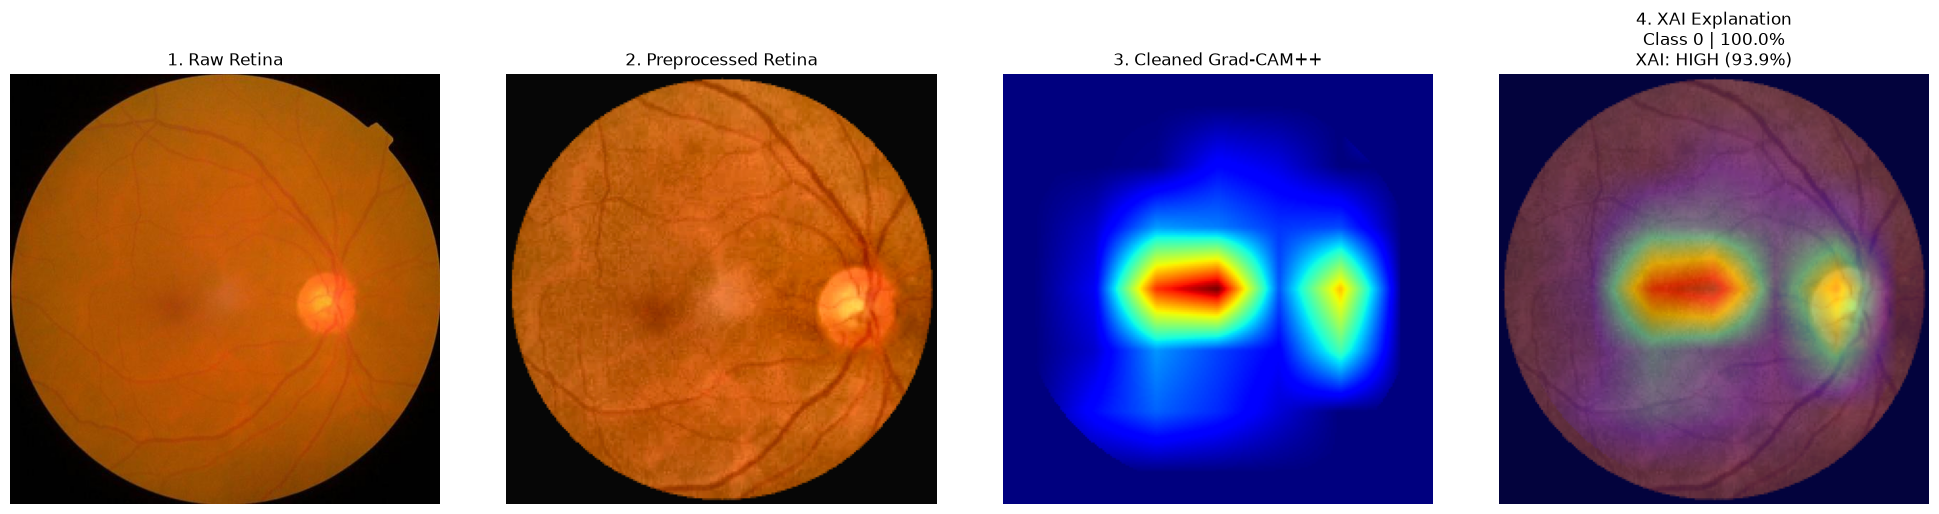

In [13]:
raw_df = pd.read_csv(
    Config.RAW_CLINICAL_CSV_PATH
)


# CHANGE THIS INDEX TO TEST DIFFERENT PATIENTS
TEST_INDEX = 6

test_row = raw_df.iloc[
    TEST_INDEX
]

image_path = (
    test_row["Image_Path"]
)

patient_profile = {

    col: test_row[col]

    for col in clinical_feature_cols

}

print(
    "True DR Grade:",
    test_row["DR_Grade"]
)

print(
    "Image:",
    image_path
)

result = predict_with_xai(

    image_path=image_path,

    patient_profile=patient_profile

)

Cell 14 — Automatically Test One Sample From Every Class





TESTING TRUE CLASS 0

MULTIMODAL DR PREDICTION
Predicted DR Class : 2
Confidence         : 51.59%
XAI Attention Score: 70.07%
XAI Reliability    : MEDIUM


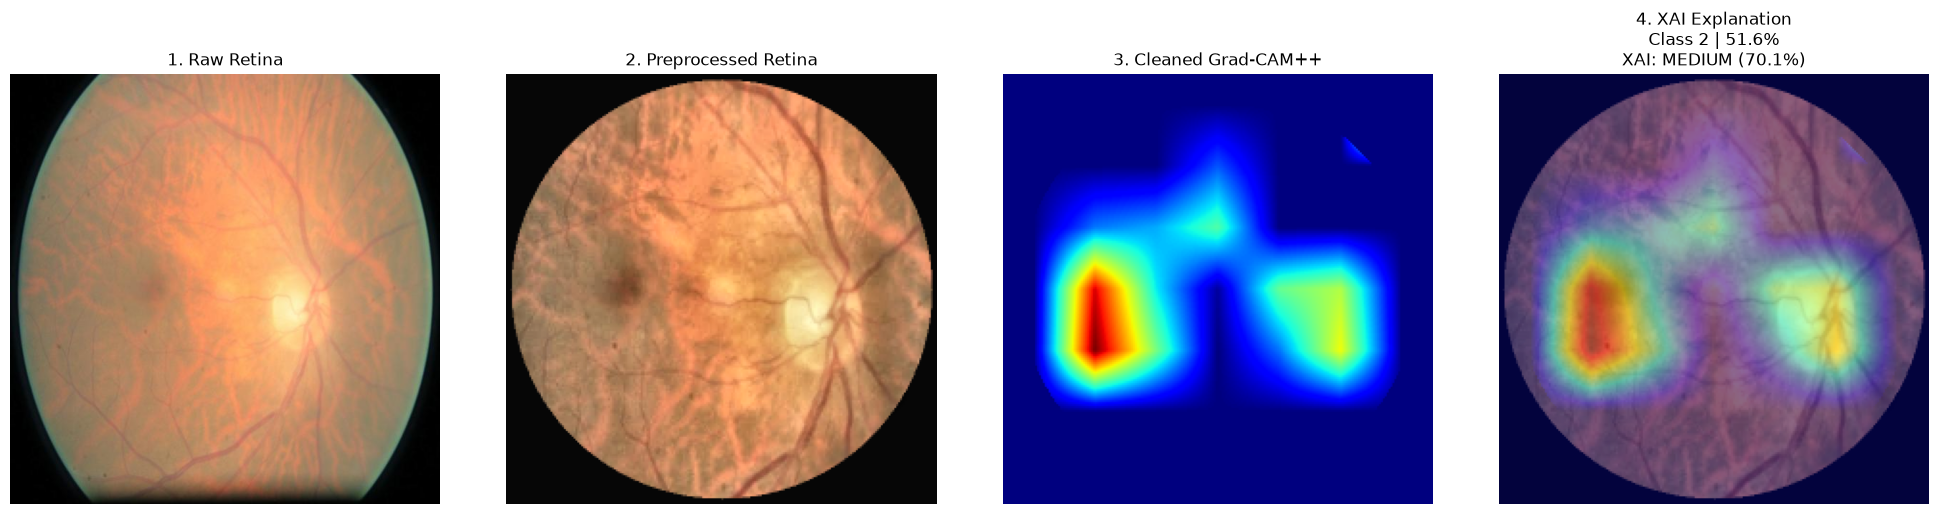


TRUE CLASS      : 0
PREDICTED CLASS : 2
CONFIDENCE      : 51.59%
XAI RELIABILITY : MEDIUM (70.07%)



TESTING TRUE CLASS 1

MULTIMODAL DR PREDICTION
Predicted DR Class : 1
Confidence         : 99.98%
XAI Attention Score: 75.57%
XAI Reliability    : MEDIUM


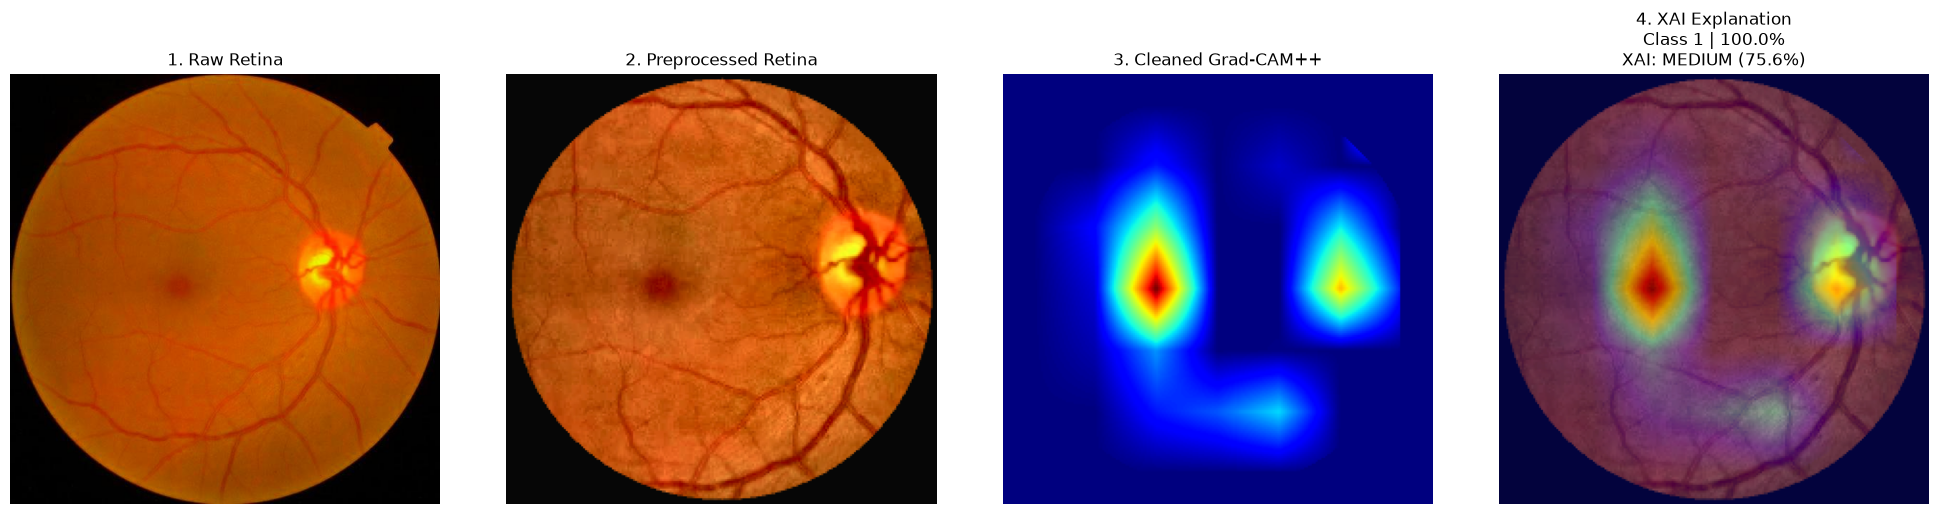


TRUE CLASS      : 1
PREDICTED CLASS : 1
CONFIDENCE      : 99.98%
XAI RELIABILITY : MEDIUM (75.57%)



TESTING TRUE CLASS 2

MULTIMODAL DR PREDICTION
Predicted DR Class : 2
Confidence         : 51.55%
XAI Attention Score: 92.25%
XAI Reliability    : HIGH


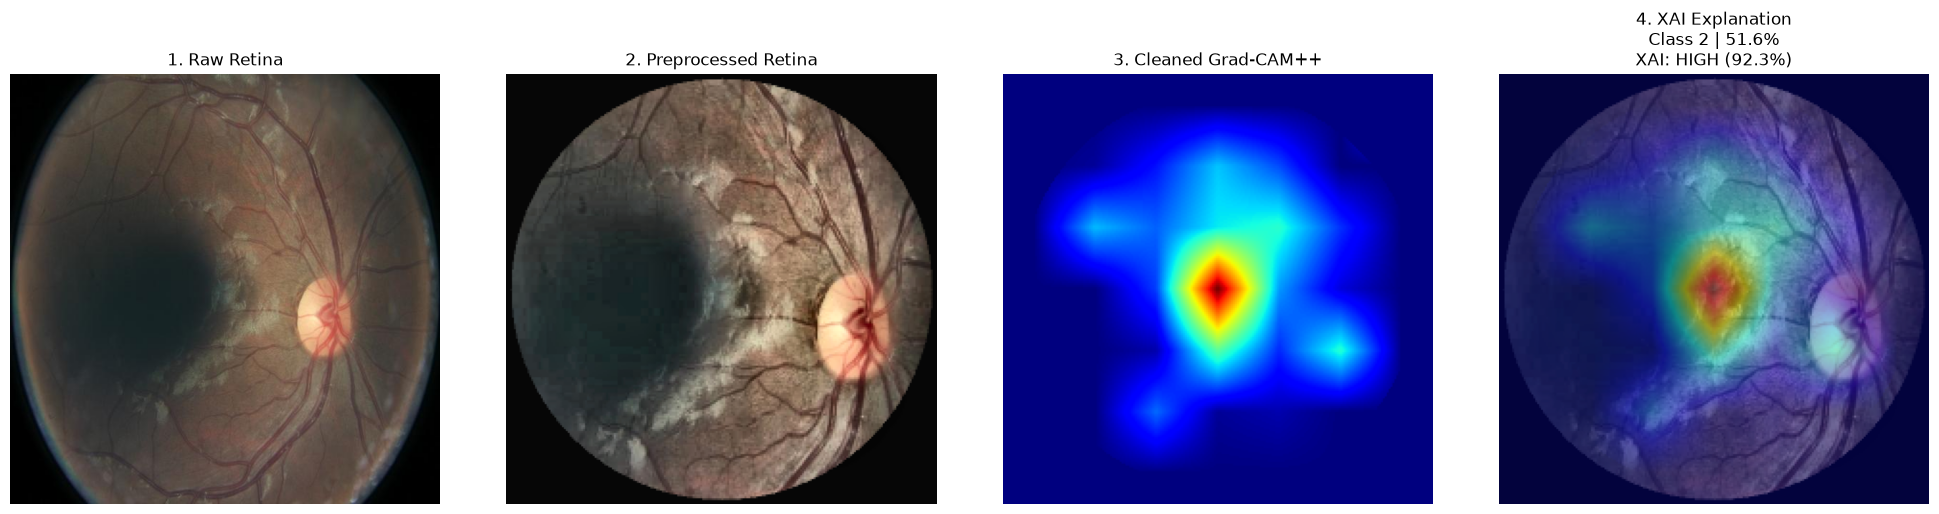


TRUE CLASS      : 2
PREDICTED CLASS : 2
CONFIDENCE      : 51.55%
XAI RELIABILITY : HIGH (92.25%)



TESTING TRUE CLASS 3

MULTIMODAL DR PREDICTION
Predicted DR Class : 3
Confidence         : 100.00%
XAI Attention Score: 39.53%
XAI Reliability    : LOW


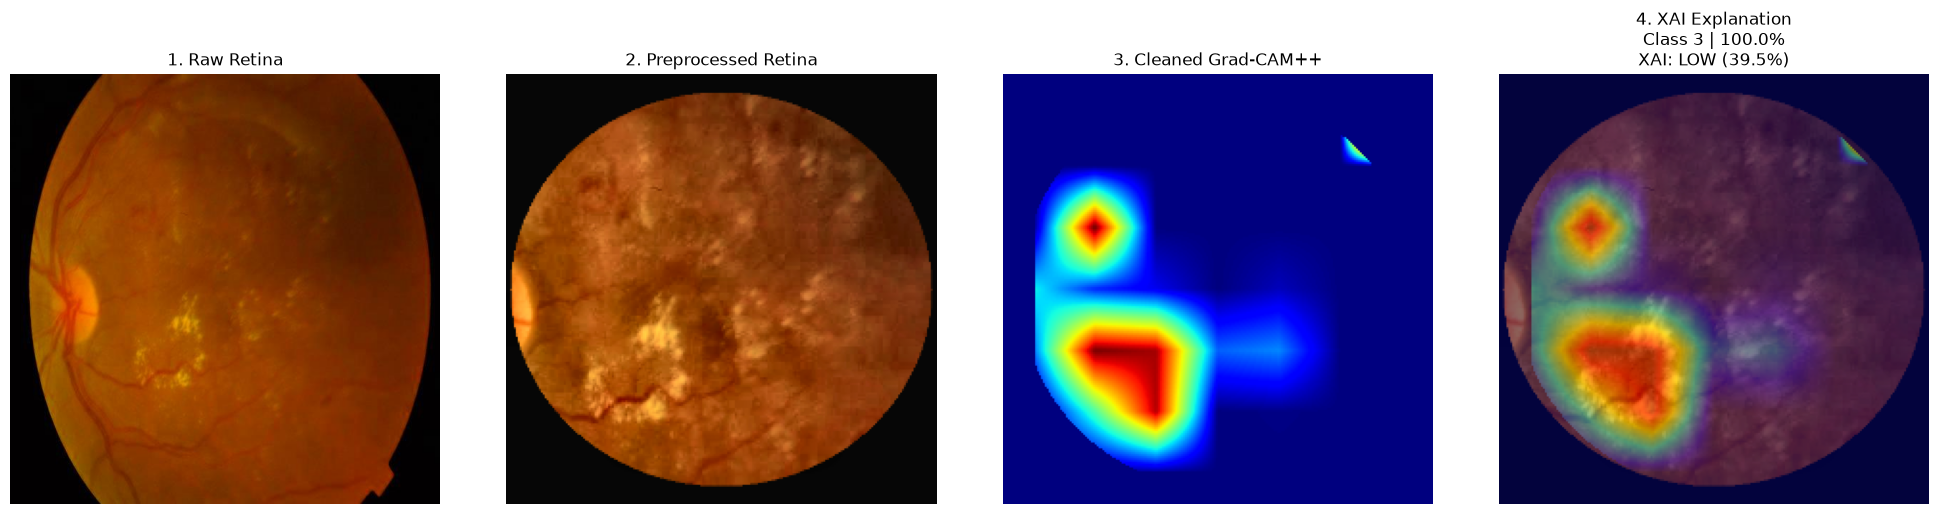


TRUE CLASS      : 3
PREDICTED CLASS : 3
CONFIDENCE      : 100.00%
XAI RELIABILITY : LOW (39.53%)



TESTING TRUE CLASS 4

MULTIMODAL DR PREDICTION
Predicted DR Class : 4
Confidence         : 100.00%
XAI Attention Score: 87.58%
XAI Reliability    : HIGH


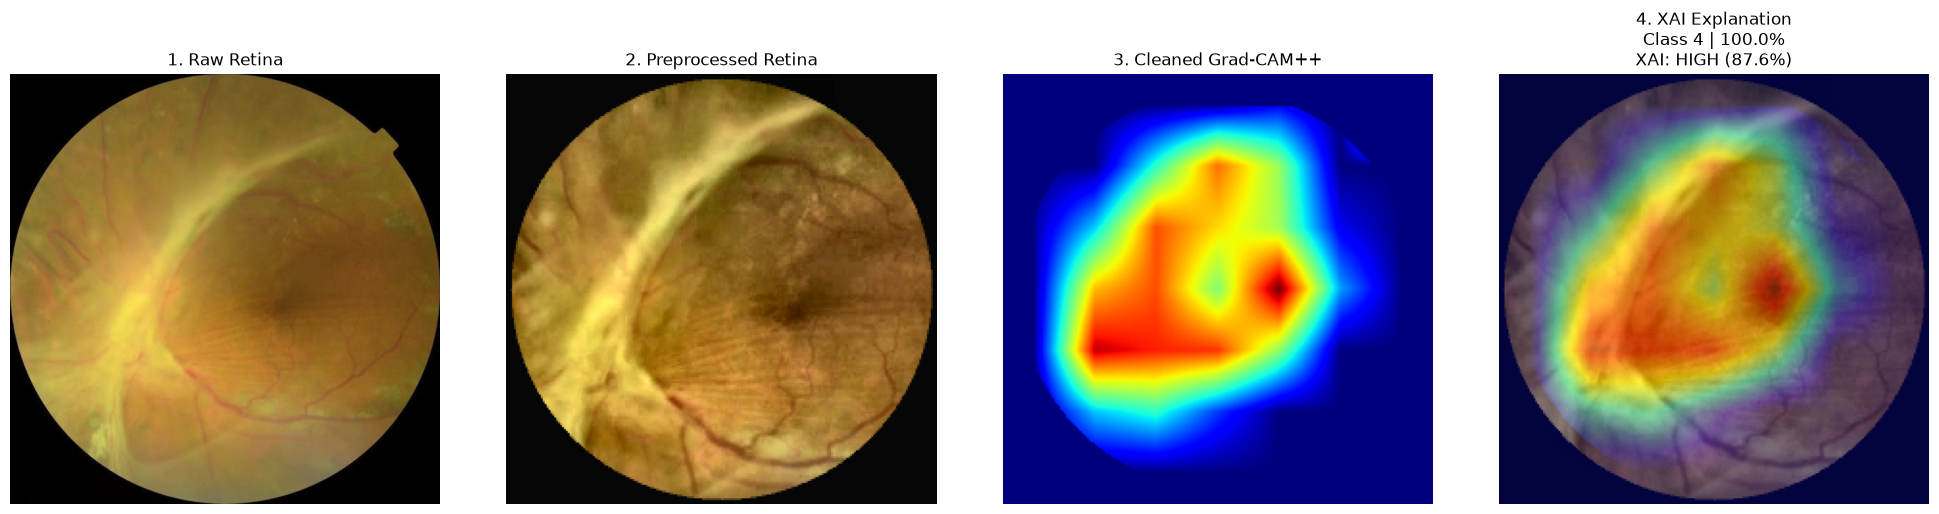


TRUE CLASS      : 4
PREDICTED CLASS : 4
CONFIDENCE      : 100.00%
XAI RELIABILITY : HIGH (87.58%)


In [14]:
for grade in range(5):

    class_samples = raw_df[
        raw_df["DR_Grade"] == grade
    ]

    if len(class_samples) == 0:

        print(
            f"No sample found for class {grade}"
        )
        continue

    # Random sample from class
    test_row = class_samples.sample(
        n=1,
        random_state=random.randint(
            0,
            10000
        )
    ).iloc[0]

    image_path = (
        test_row["Image_Path"]
    )

    patient_profile = {

        col: test_row[col]

        for col in clinical_feature_cols

    }

    print("\n\n")

    print(
        f"TESTING TRUE CLASS {grade}"
    )
    result = predict_with_xai(

        image_path=image_path,

        patient_profile=patient_profile

    )
    print(
        f"\nTRUE CLASS      : {grade}"
    )
    print(
        f"PREDICTED CLASS : "
        f"{result['predicted_class']}"
    )
    print(
        f"CONFIDENCE      : "
        f"{result['confidence'] * 100:.2f}%"
    )
    print(
        f"XAI RELIABILITY : "
        f"{result['xai_reliability']} "
        f"({result['xai_score']:.2f}%)"
    )